# $visit_n - visit_1 \rightarrow fatigue_n - fatigue_1$
$\Delta visit \rightarrow \Delta fatigue$ \
Finds difference from **first** visit to current visit **using weekly DMOs**

In [33]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.model import ModelConfig
from src.core.enums import MileStone, PatientDataType, DataFrequency
from src.core.normaliser import Normaliser
from sklearn.preprocessing import MinMaxScaler
from src.train import LSTMRegressionXV
from src.core.data_transforms import Transform

import torch

In [34]:
K_FOLDS = 5
N_VISITS = 4

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [36]:
from torch.nn import HuberLoss, CrossEntropyLoss, MSELoss
from torch.optim import Adam

config = ModelConfig(
    name="lstm_regression",
    model_type="LSTM",
    input_size=169,
    hidden_size=128,
    num_layers=1,
    output_size=1,
    batch_size=16,
    epochs=50,
    optimiser=Adam,
    loss_fn=MSELoss(),
    learning_rate=5e-4,
)

config.notes = "None"

In [37]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
]

In [38]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
    physical_subset=True,
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [39]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [40]:
dmo_data, dmo_labels = Transform.get_patient_visits(dmo_data, dmo_labels, n_visits=N_VISITS)

In [41]:
# remove patients that don't have a full dataset
patient_indexs = []
patient, visit, day, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
fatigue_labels = dmo_labels[patient_indexs]

In [42]:
print(dmo_data.shape)

torch.Size([428, 4, 7, 24])


In [43]:
# Min max normalise all fatigue values
physical_subset_max = 36
fatigue_labels = fatigue_labels / physical_subset_max

In [44]:
dmo_data = dmo_data.flatten(start_dim=2, end_dim=3)

In [45]:
dmo_data.shape

torch.Size([428, 4, 168])

In [46]:
first_visit = dmo_data[:, 0:1, :]

delta_visits = dmo_data - first_visit
delta_visits = delta_visits[:, 1:]
delta_visits.shape  

torch.Size([428, 3, 168])

In [47]:
first_fatigue = fatigue_labels[:, 0:1, :]

prev_fatigue = fatigue_labels[:, :-1, :]
target_y = fatigue_labels - first_fatigue
target_y = target_y[:, 1:, :]

In [48]:
input_data = torch.cat((delta_visits, prev_fatigue), dim=2)
label_data = target_y

In [49]:
input_data.shape

torch.Size([428, 3, 169])

In [50]:
label_data.shape

torch.Size([428, 3, 1])

In [51]:
xv_trainer = LSTMRegressionXV(input_data, label_data, config, device, k=K_FOLDS)
prediction, actual = xv_trainer.train_cross_validation()

Testing loss: 0.0368621110295256
Testing loss: 0.04038378596305847
Testing loss: 0.0489601610849301
Testing loss: 0.035419460851699114
Testing loss: 0.04333867815633615


In [52]:
prediction = torch.concatenate(prediction).flatten()
prediction = (prediction * physical_subset_max).flatten()
prediction.shape

torch.Size([1284])

In [53]:
actual = torch.concatenate(actual).flatten()
actual = (actual * physical_subset_max).flatten()
actual.shape

torch.Size([1284])

In [54]:
print(xv_trainer.R2_values)

[-0.4502784013748169, -0.41750621795654297, -0.7894421815872192, -0.33192873001098633, -0.527530312538147]


All metrics: {'accuracy': 0.011682242990654205, 'Mean Squared Error': 51.95591735839844, 'Mean Absolute Error': 5.602302074432373, 'R^2': -0.472304105758667}


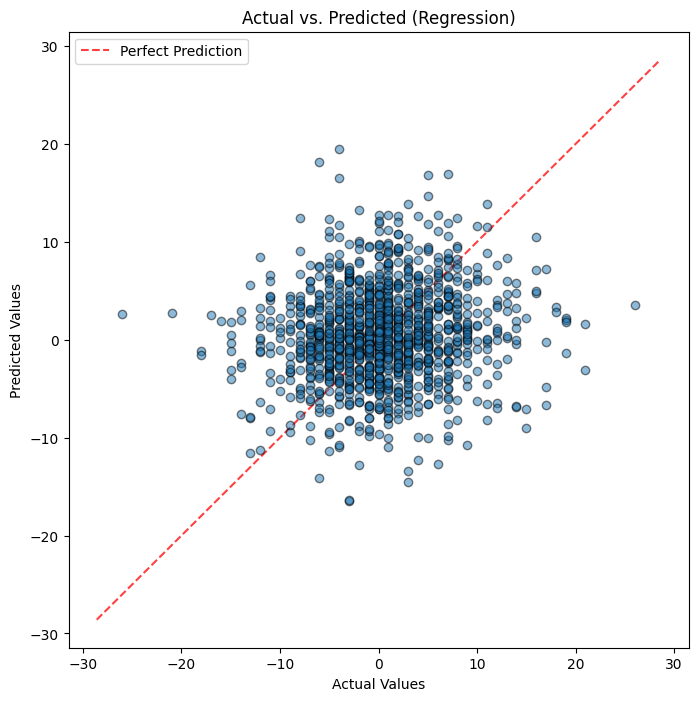

In [55]:
from src.evaluation import Evaluation

evaluation = Evaluation(prediction, actual)
print(f"All metrics: {evaluation.compute_all_metrics()}")
evaluation.evaluation_plot().show()
